# NeuroDermAI Kaggle Training Notebook

This notebook trains a real transfer-learning image classifier for common skin conditions using TensorFlow/Keras on Kaggle GPU.

Canonical classes:
- `acne`
- `eczema`
- `psoriasis`
- `fungal`
- `warts`
- `normal`

How it works:
1. Reads image data from `/kaggle/input/...`
2. Maps dataset folder names into the canonical class set when safe aliases are found
3. Builds a clean directory at `/kaggle/working/curated_dataset/`
4. Trains a MobileNetV2 classifier with augmentation and class weights
5. Saves `/kaggle/working/model.h5` and `/kaggle/working/labels.json`

If the attached dataset does not include healthy images, the exported model will not include the `normal` class. That limitation is intentional and should be documented honestly in the app README.

In [2]:
import json
import re
import shutil
from collections import Counter
from pathlib import Path
from uuid import uuid4
from tqdm import tqdm



import numpy as np
import tensorflow as tf


SEED = 42
IMAGE_SIZE = (224, 224)
strategy = tf.distribute.MirroredStrategy()
print(f'Number of devices: {strategy.num_replicas_in_sync}')
BATCH_SIZE = 32 * strategy.num_replicas_in_sync
VALIDATION_SPLIT = 0.2
INITIAL_EPOCHS = 8
FINE_TUNE_EPOCHS = 5
MIN_IMAGES_PER_CLASS = 10

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
WORKING_DIR = Path("/kaggle/working")
DATASET_DIR = Path("/kaggle/input/datasets/shubhamgoel27/dermnet/train")

TARGET_CLASSES = ["acne", "eczema", "psoriasis", "fungal", "warts", "normal"]
CLASS_ALIASES = {
    "acne": ["acne", "acne vulgaris", "pimple", "pimples"],
    "eczema": ["eczema", "atopic dermatitis"],
    "psoriasis": ["psoriasis", "psoriatic"],
    "fungal": ["fungal", "fungal infection", "ringworm", "tinea", "candidiasis"],
    "warts": ["warts", "wart", "verruca"],
    "normal": ["normal", "healthy", "clear skin", "no disease"],
}
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))


def normalise_name(raw_name: str) -> str:
    cleaned = re.sub(r"[^a-z0-9]+", " ", raw_name.lower())
    return re.sub(r"\s+", " ", cleaned).strip()


def canonical_class_name(raw_name: str):
    normalized = normalise_name(raw_name)
    for canonical, aliases in CLASS_ALIASES.items():
        if normalized == canonical:
            return canonical
        for alias in aliases:
            alias_normalized = normalise_name(alias)
            if alias_normalized and alias_normalized in normalized:
                return canonical
    return None


def discover_dataset_dir() -> Path:
    if DATASET_DIR:
        dataset_path = Path(DATASET_DIR)
        if not dataset_path.exists():
            raise FileNotFoundError(f"Configured DATASET_DIR does not exist: {dataset_path}")
        return dataset_path

    candidates = [path for path in KAGGLE_INPUT_ROOT.iterdir() if path.is_dir()]
    if not candidates:
        raise FileNotFoundError("No attached Kaggle datasets were found under /kaggle/input.")

    if len(candidates) == 1:
        return candidates[0]

    scored_candidates = []
    for candidate in candidates:
        score = 0
        for subdir in candidate.rglob("*"):
            if subdir.is_dir() and canonical_class_name(subdir.name):
                score += 1
        scored_candidates.append((score, candidate))

    scored_candidates.sort(key=lambda item: item[0], reverse=True)
    print("Autodetected dataset candidates:")
    for score, path in scored_candidates[:5]:
        print(f"  score={score}: {path}")

    best_score, best_candidate = scored_candidates[0]
    if best_score == 0:
        raise ValueError(
            "Could not infer a matching dataset from /kaggle/input. Set DATASET_DIR to the correct folder."
        )
    return best_candidate


def infer_class_from_path(image_path: Path, dataset_dir: Path):
    relative_parts = image_path.relative_to(dataset_dir).parts[:-1]
    for part in reversed(relative_parts):path
        canonical = canonical_class_name(part)
        if canonical:
            return canonical
    return None


def build_curated_dataset(source_dir: Path):
    curated_dir = WORKING_DIR / "curated_dataset"
    if curated_dir.exists():
        shutil.rmtree(curated_dir)
    curated_dir.mkdir(parents=True, exist_ok=True)

    counts = Counter()

    for image_path in source_dir.rglob("*"):
        if not image_path.is_file() or image_path.suffix.lower() not in SUPPORTED_EXTENSIONS:
            continue

        canonical = infer_class_from_path(image_path, source_dir)
        if canonical is None:
            continue

        destination_dir = curated_dir / canonical
        destination_dir.mkdir(parents=True, exist_ok=True)

        parent_stub = normalise_name(str(image_path.relative_to(source_dir).parent)).replace(" ", "_")
        destination_name = f"{parent_stub}_{uuid4().hex[:10]}{image_path.suffix.lower()}"
        shutil.copy2(image_path, destination_dir / destination_name)
        counts[canonical] += 1

    if not counts:
        raise ValueError(
            "No labeled images matched the canonical class aliases. Attach a dataset whose folder names include supported labels."
        )

    available_counts = {}
    for class_name in TARGET_CLASSES:
        class_dir = curated_dir / class_name
        image_count = counts.get(class_name, 0)

        if image_count == 0:
            if class_dir.exists():
                shutil.rmtree(class_dir)
            continue

        if image_count < MIN_IMAGES_PER_CLASS:
            print(
                f"Skipping '{class_name}' because only {image_count} images were found, below MIN_IMAGES_PER_CLASS={MIN_IMAGES_PER_CLASS}."
            )
            shutil.rmtree(class_dir)
            continue

        available_counts[class_name] = image_count

    if len(available_counts) < 2:
        raise ValueError(
            "Training requires at least two usable classes after dataset curation."
        )

    return curated_dir, available_counts


source_dir = discover_dataset_dir()
curated_dir, class_counts = build_curated_dataset(source_dir)

print(f"Using source dataset: {source_dir}")
print(f"Curated dataset written to: {curated_dir}")
print("Usable class counts:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count}")

if "normal" not in class_counts:
    print(
        "NOTE: No usable 'normal' class was found. The exported model will only predict the available disease classes."
    )


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1775399377.348274      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775399377.354179      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Number of devices: 2
TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Using source dataset: /kaggle/input/datasets/shubhamgoel27/dermnet/train
Curated dataset written to: /kaggle/working/curated_dataset
Usable class counts:
  acne: 840
  eczema: 1724
  psoriasis: 1405
  fungal: 1300
  warts: 1086
NOTE: No usable 'normal' class was found. The exported model will only predict the available disease classes.


In [3]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE
TOP_K = min(3, len(class_counts))

# =========================
# LOAD DATASET
# =========================
raw_train_ds = keras.utils.image_dataset_from_directory(
    curated_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

raw_val_ds = keras.utils.image_dataset_from_directory(
    curated_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = raw_train_ds.class_names
print("Training classes:", class_names)

# =========================
# AUGMENTATION
# =========================
augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.RandomContrast(0.12),
    ],
    name="augmentation",
)

# =========================
# PREPROCESSING
# =========================
def prepare_train(images, labels):
    images = tf.cast(images, tf.float32)
    images = augmentation(images, training=True)
    images = preprocess_input(images)
    return images, labels


def prepare_eval(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels


# ✅ FIX: added cache + shuffle
train_ds = (
    raw_train_ds
    .map(prepare_train, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    raw_val_ds
    .map(prepare_eval, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

# =========================
# CLASS WEIGHTS
# =========================
total_images = sum(class_counts[class_name] for class_name in class_names)

class_weight = {
    index: round(total_images / (len(class_names) * class_counts[class_name]), 4)
    for index, class_name in enumerate(class_names)
}

print("Class weights:", class_weight)

# =========================
# MODEL
# =========================
with strategy.scope():
    base_model = MobileNetV2(
        input_shape=IMAGE_SIZE + (3,),
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = keras.Input(shape=IMAGE_SIZE + (3,), name="image")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)   # ✅ added for stability
    x = layers.Dropout(0.35)(x)

    outputs = layers.Dense(len(class_names), activation="softmax", dtype="float32")(x)

    model = keras.Model(inputs, outputs, name="neurodermai_mobilenetv2")

    metrics = [
        keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        keras.metrics.SparseTopKCategoricalAccuracy(k=TOP_K, name="top_3_accuracy"),
    ]

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=metrics,
    )

# =========================
# CALLBACKS
# =========================
checkpoint_path = WORKING_DIR / "best_model.keras"

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6),
]

# =========================
# TRAIN (HEAD)
# =========================
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

# =========================
# FINE-TUNING
# =========================
with strategy.scope():
    base_model.trainable = True

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=metrics,
    )

# ✅ FIX: stable epoch handling
history_fine_tune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS + FINE_TUNE_EPOCHS,
    initial_epoch=INITIAL_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
)

# =========================
# EVALUATION
# =========================
best_model = keras.models.load_model(checkpoint_path)

val_probabilities = best_model.predict(val_ds, verbose=0)
val_true = np.concatenate([labels.numpy() for _, labels in raw_val_ds], axis=0)
val_pred = np.argmax(val_probabilities, axis=1)

print(classification_report(val_true, val_pred, target_names=class_names, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(val_true, val_pred))

# =========================
# SAVE MODEL
# =========================
labels_payload = {
    "class_names": class_names,
    "image_size": list(IMAGE_SIZE),
    "backbone": "MobileNetV2",
    "validation_split": VALIDATION_SPLIT,
}

model_path = WORKING_DIR / "model.h5"
labels_path = WORKING_DIR / "labels.json"

best_model.save(model_path)

with labels_path.open("w", encoding="utf-8") as handle:
    json.dump(labels_payload, handle, indent=2)

print(f"Saved model to: {model_path}")
print(f"Saved labels to: {labels_path}")

Found 6355 files belonging to 5 classes.
Using 5084 files for training.
Found 6355 files belonging to 5 classes.
Using 1271 files for validation.
Training classes: ['acne', 'eczema', 'fungal', 'psoriasis', 'warts']
Class weights: {0: 1.5131, 1: 0.7372, 2: 0.9777, 3: 0.9046, 4: 1.1703}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost

I0000 00:00:1775399862.367913     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775399862.367930     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


80/80 ━━━━━━━━━━━━━━━━━━━━ 23s 165ms/step - accuracy: 0.1962 - loss: 2.5447 - top_3_accuracy: 0.6111 - val_accuracy: 0.2400 - val_loss: 1.8475 - val_top_3_accuracy: 0.6349 - learning_rate: 1.0000e-04
Epoch 2/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.2600 - loss: 2.1679 - top_3_accuracy: 0.6770 - val_accuracy: 0.2982 - val_loss: 1.7209 - val_top_3_accuracy: 0.6806 - learning_rate: 1.0000e-04
Epoch 3/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.3026 - loss: 1.9760 - top_3_accuracy: 0.7229 - val_accuracy: 0.3383 - val_loss: 1.6644 - val_top_3_accuracy: 0.7175 - learning_rate: 1.0000e-04
Epoch 4/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.3325 - loss: 1.8414 - top_3_accuracy: 0.7495 - val_accuracy: 0.3619 - val_loss: 1.6314 - val_top_3_accuracy: 0.7364 - learning_rate: 1.0000e-04
Epoch 5/8
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.3507 - loss: 1.7939 - top_3_accuracy: 0.7506 - val_accuracy: 0.3784 - val_loss: 1.6022 - val_top_3_accuracy:

              precision    recall  f1-score   support

        acne       0.12      0.19      0.15       148
      eczema       0.29      0.30      0.29       331
      fungal       0.24      0.12      0.16       288
   psoriasis       0.22      0.15      0.18       278
       warts       0.20      0.33      0.25       226

    accuracy                           0.22      1271
   macro avg       0.21      0.22      0.21      1271
weighted avg       0.23      0.22      0.21      1271

Confusion matrix:
 [[28 34 17 20 49]
 [56 98 28 54 95]
 [56 69 34 50 79]
 [42 84 34 41 77]
 [45 55 26 25 75]]
Saved model to: /kaggle/working/model.h5
Saved labels to: /kaggle/working/labels.json


Ground truth: warts

Top predictions:
1. warts → 41.86%
2. eczema → 22.63%
3. fungal → 19.26%


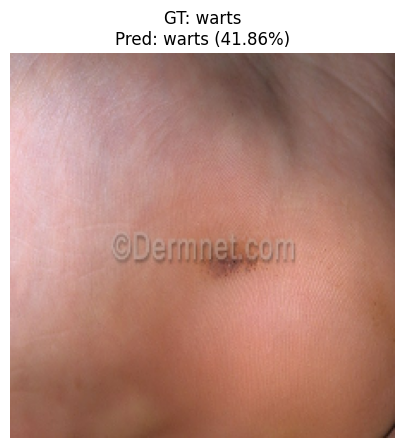

In [14]:
import matplotlib.pyplot as plt

# Get one batch
sample_images, sample_labels = next(iter(raw_val_ds.take(1)))

sample_image = sample_images[0].numpy().astype("uint8")
ground_truth = class_names[int(sample_labels[0].numpy())]

# Preprocess properly
sample_input = preprocess_input(tf.cast(sample_images[:1], tf.float32))

# Predict
sample_probabilities = best_model.predict(sample_input, verbose=0)[0]
top_indices = sample_probabilities.argsort()[::-1][:TOP_K]

# Print results
print(f"Ground truth: {ground_truth}")
print("\nTop predictions:")
for rank, index in enumerate(top_indices, start=1):
    print(f"{rank}. {class_names[index]} → {sample_probabilities[index]*100:.2f}%")

# =========================
# VISUALIZATION (Improved)
# =========================
plt.figure(figsize=(5, 5))
plt.imshow(sample_image)
plt.axis("off")

# Show top prediction on image
top_pred = class_names[top_indices[0]]
confidence = sample_probabilities[top_indices[0]] * 100

plt.title(f"GT: {ground_truth}\nPred: {top_pred} ({confidence:.2f}%)")
plt.show()